# Final Exam BUS 458 — Loan Data Analysis
**Objective:** Your objective is to identify the key drivers of loan approval and recommend which lender should be prioritized for each customer to maximize total payout

### **Instructions**
- Follow the prompts in each section of this notebook.
- **Where you see a “Question,” answer it directly below in a Markdown (text) cell — not as a code comment.**
- Your **reasoning, interpretations, and insights** should be written in text cells, clearly separated from code.
- You are encouraged to add extra **code cells**, **visualizations**, or **short explanations** if they strengthen your analysis or help you justify decisions.
- Make sure your notebook runs cleanly from start to finish without errors.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Load Data (via Google Drive or direct upload)

In [142]:
import streamlit as st
import pandas as pd

uploaded_file = st.file_uploader("loan_data_analysis_final.csv")

if uploaded_file is not None:
  df=pd.read_csv(uploaded_file)
  st.write(df)

2026-04-24 19:36:11.731 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 19:36:11.734 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 19:36:11.739 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 19:36:11.744 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 19:36:11.745 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 19:36:11.747 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
# Check first 5 rows of dataframe
df.head()

,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
0,cover_an_unexpected_cost,100000,123000.0,669.0,fair,full_time,consumer_discretionary,5024.0,927,0,B,0,0
1,credit_card_refinancing,70000,79000.0,594.0,fair,full_time,information_technology,5764.0,1177,0,B,0,0
2,home_improvement,10000,11000.0,596.0,fair,full_time,information_technology,4017.0,1487,0,A,0,0
3,home_improvement,100000,120000.0,642.0,fair,part_time,energy,3129.0,904,0,A,0,0
4,major_purchase,30000,34000.0,NaN,fair,full_time,energy,NaN,1620,0,A,0,0


In [ ]:
# Drop columns that have no variation or are unique

unique_counts = df.nunique()

print("Unique Value Counts for Columns:\n",unique_counts)

# Columns to Drop (based on initial analysis, though they might be missing if df was preprocessed upstream):
# 'User ID': Has 100,000 unique values (which is equal to the number of rows), so it is an unique identifer.
# 'applications': Has only 1 unique value, meaning it has no variation and won't help the model.
intended_columns_to_drop = ['User ID', 'applications']

# Filter to only drop columns that actually exist in the DataFrame
columns_to_drop_present = [col for col in intended_columns_to_drop if col in df.columns]

# Handle duplicates before dropping columns, if any remain
df.duplicated().sum()
df.drop_duplicates(inplace=True)

if columns_to_drop_present:
    df = df.drop(columns=columns_to_drop_present)
    print(f"Dropped columns: {columns_to_drop_present}")
else:
    print(f"No columns from {intended_columns_to_drop} were found to drop.")

print(f"New shape: {df.shape}")

Unique Value Counts for Columns:
 Reason                            6
Granted_Loan_Amount              12
Requested_Loan_Amount           459
FICO_score                      551
Fico_Score_group                  5
Employment_Status                 3
Employment_Sector                11
Monthly_Gross_Income          12330
Monthly_Housing_Payment        3002
Ever_Bankrupt_or_Foreclose        2
Lender                            3
Approved                          2
bounty                            4
dtype: int64
No columns from ['User ID', 'applications'] were found to drop.
New shape: (100000, 13)


Understand the Data: Get a quick overview of the dataset structure and variable meanings before preprocessing.

In [ ]:
print("DataFrame Info:")
df.info()

print("\nDataFrame Description (Numerical Columns):")

# Display descriptive statistics for numerical columns
display(df.describe())

print("\nMissing Values Count:")
# Display the count of missing values for each column
display(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Reason                      100000 non-null  object 
 1   Granted_Loan_Amount         100000 non-null  int64  
 2   Requested_Loan_Amount       100000 non-null  float64
 3   FICO_score                  85000 non-null   float64
 4   Fico_Score_group            100000 non-null  object 
 5   Employment_Status           100000 non-null  object 
 6   Employment_Sector           93593 non-null   object 
 7   Monthly_Gross_Income        85000 non-null   float64
 8   Monthly_Housing_Payment     100000 non-null  int64  
 9   Ever_Bankrupt_or_Foreclose  100000 non-null  int64  
 10  Lender                      100000 non-null  object 
 11  Approved                    100000 non-null  int64  
 12  bounty                      100000 non-null  int64  
dtyp

,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Approved,bounty
count,1.000000e+05,1.000000e+05,85000.000000,85000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,6.478465e+04,7.450309e+04,629.338153,5808.783776,1888.900720,0.022460,0.109760,26.415000
std,1.965837e+05,2.264856e+05,88.684201,2988.185274,3431.924282,0.148175,0.312592,78.385644
min,5.000000e+03,5.000000e+03,300.000000,-17702.000000,300.000000,0.000000,0.000000,0.000000
25%,2.000000e+04,2.400000e+04,572.000000,3659.000000,1231.000000,0.000000,0.000000,0.000000
50%,4.000000e+04,4.400000e+04,634.000000,5153.500000,1669.000000,0.000000,0.000000,0.000000
75%,7.000000e+04,8.400000e+04,693.000000,7612.000000,2051.000000,0.000000,0.000000,0.000000
max,2.000000e+06,2.500000e+06,850.000000,19997.000000,49500.000000,1.000000,1.000000,350.000000



Missing Values Count:


,0
Reason,0
Granted_Loan_Amount,0
Requested_Loan_Amount,0
FICO_score,15000
Fico_Score_group,0
Employment_Status,0
Employment_Sector,6407
Monthly_Gross_Income,15000
Monthly_Housing_Payment,0
Ever_Bankrupt_or_Foreclose,0


## 1. Preprocessing


### 1.1 Handling Missing Values

**Question:** Why is median imputation often preferable to mean imputation for income and FICO?


**Answer:** It is to pevent outliers from being accounted. The mean for income and FICO is calculated with all values, outliers included, which could skew the data. The median is the middle number out of the data, which is not affected by outliers.





In [ ]:
# Calculate the number of missing values per column
missing_values = df.isnull().sum()

# Calculate the percentage of missing values per column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display missing values counts and percentages
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Filter to show only columns with missing values and sort by percentage
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Missing Values Information:")
display(missing_info)

Missing Values Information:


,Missing Count,Missing Percentage
FICO_score,15000,15.000
Monthly_Gross_Income,15000,15.000
Employment_Sector,6407,6.407


In [ ]:
# Apply imputation as instructed in the instructions pdf (create copies so original rows can be restored if needed)

# Impute
df_copy = df.copy()
df_copy['FICO_score'] = df_copy['FICO_score'].fillna(df_copy['FICO_score'].median())
df_copy['Monthly_Gross_Income'] = df_copy['Monthly_Gross_Income'].fillna(df_copy['Monthly_Gross_Income'].median())
df_copy['Employment_Sector'] = df_copy['Employment_Sector'].fillna('Unknown')

print("Missing values after imputation:")
print(df_copy.isnull().sum().sum())


Missing values after imputation:
0


### 1.2 Outliers Detection and Removal

**Question:**
Which features had the most outliers, and what impact could they have on the model?

**Answer** : Add your answer here

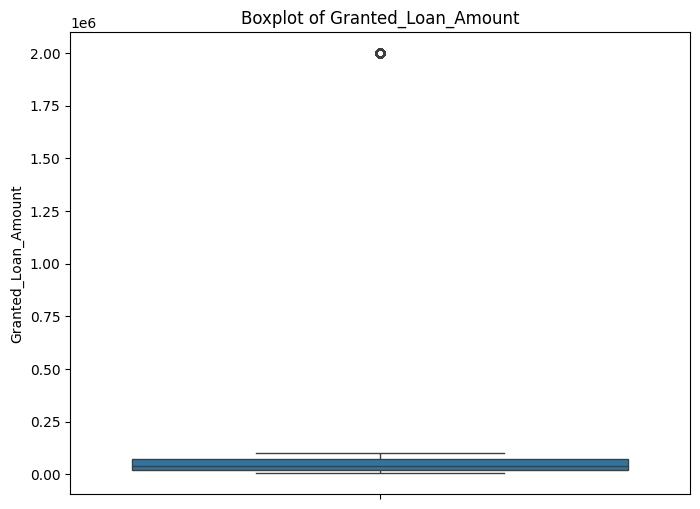

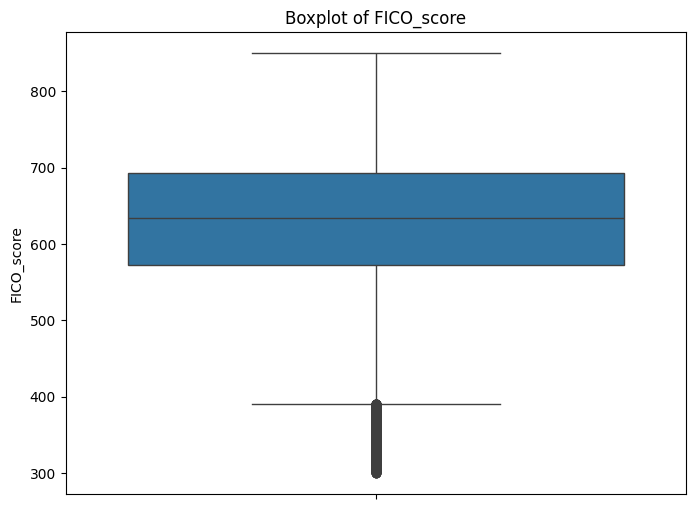

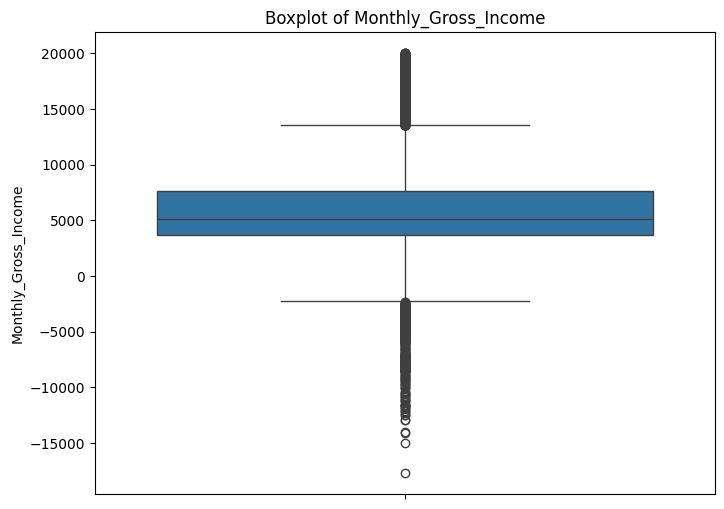

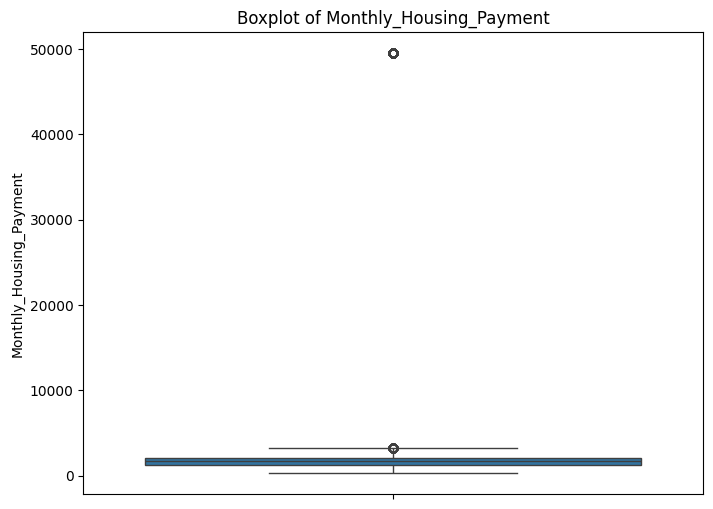

In [146]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

numeric_cols = ['Granted_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

# Boxplots to highlight outliers for numerical columns
for column in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
    plt.show()

In [147]:
# Remove Outliers using Z-score

from scipy import stats
import numpy as np

# Compute Z-scores for only numeric columns
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))

# Choose threshold
threshold = 3  # common choice: 3 standard deviations

# Identify rows to keep (all Z-scores <= threshold)
rows_to_keep = (z_scores < threshold).all(axis=1)

# Track counts before/after
before_count = df.shape[0]
df_clean = df[rows_to_keep].copy()
after_count = df_clean.shape[0]

print(f"Outlier removal complete:")
print(f"Rows before: {before_count}")
print(f"Rows after:  {after_count}")
print(f"Rows removed: {before_count - after_count}")



Outlier removal complete:
Rows before: 100000
Rows after:  69831
Rows removed: 30169


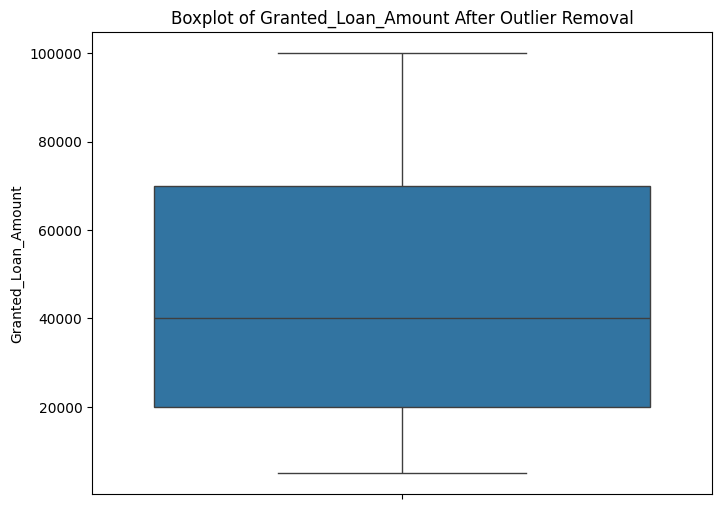

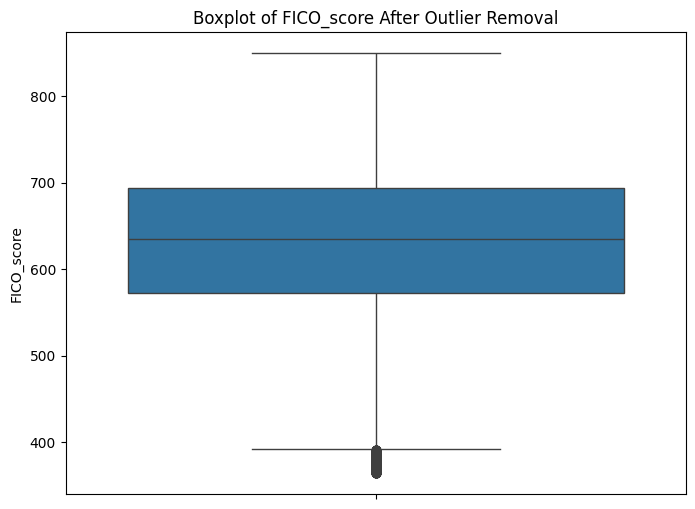

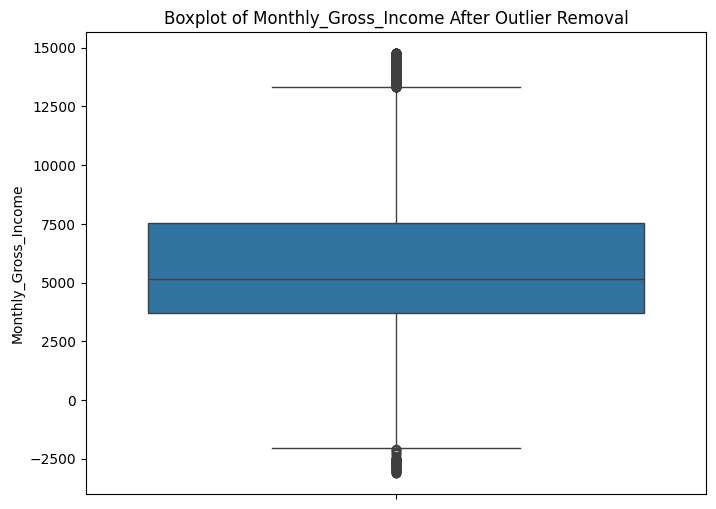

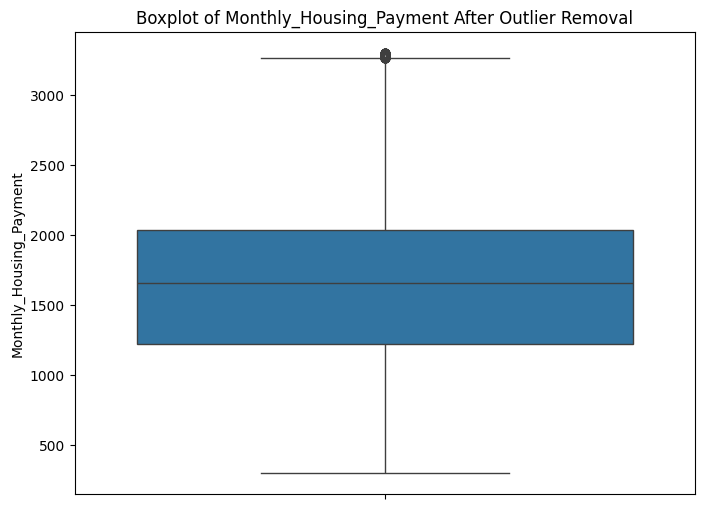

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['Granted_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

# Boxplots to highlight outliers for numerical columns using the cleaned data
for column in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df_clean[column])
    plt.title(f'Boxplot of {column} After Outlier Removal')
    plt.ylabel(column)
    plt.show()

**Question:**
Why do we need to remove or treat outliers? Provide reasoning based on model performance or data integrity.

**Answer** : Outliers should be removed because they causes errors in the model. It skews the overall data set which affects overall performance of the model by lowering accuracy, creating biases and misleading patterns.


**Question:**
Is there a difference between boxplots before and after outlier removal?

**Answer** : Yes there is. The boxplots before has a wider spread overall with more points outside the whisker. Compared to the boxplot after removal, the one before may be skewed to a side, indicating biases caused by the outliers.

### 1.3 Redundancy & Correlation Check (5 Marks)

Detect duplicate data and multicollinearity.

**Question:**
Which numerical variables appear most strongly correlated with each other?

**Answer:** Based on numerical variables, the most correlated variables would be FICO Score and Monthly Gtross Income with a 0.29 correlation.



**Question:**
Which numerical and categorical are strongly corelated to each other?

**Answer:** Based on numerical and categorical variables, the most correlated would be FICO Score and whether it is approved with a 0.27 correlation.


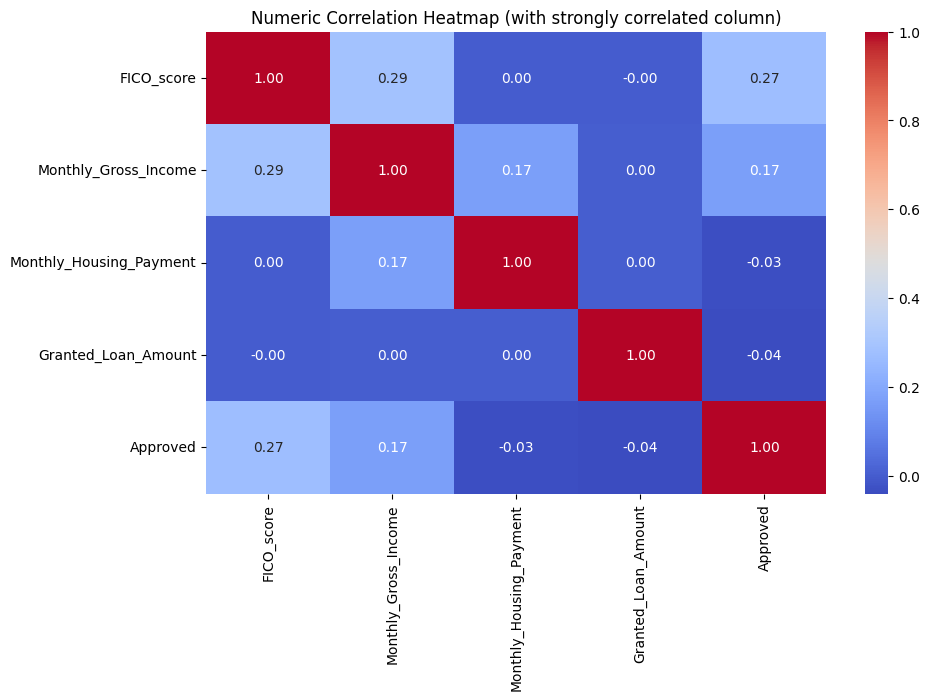

In [149]:
# Correlation between numerical features
numeric_cols = ['FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment', 'Granted_Loan_Amount', 'Approved']

# Plot correlation matrix, identify highly correlated pairs automatically (|corr|>0.95, excluding self-correlation)
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Numeric Correlation Heatmap (with strongly correlated column)")
plt.show()

Top 10 Numeric-Categorical Correlation Ratios (η²):
FICO_score - Fico_Score_group: η² = 0.850 (η = 0.922)
Monthly_Gross_Income - Employment_Status: η² = 0.282 (η = 0.531)
Monthly_Gross_Income - Fico_Score_group: η² = 0.095 (η = 0.308)
Monthly_Gross_Income - Employment_Sector: η² = 0.081 (η = 0.285)
Monthly_Housing_Payment - Employment_Status: η² = 0.040 (η = 0.199)
Ever_Bankrupt_or_Foreclose - Employment_Status: η² = 0.030 (η = 0.174)
Monthly_Housing_Payment - Lender: η² = 0.028 (η = 0.167)
Ever_Bankrupt_or_Foreclose - Employment_Sector: η² = 0.026 (η = 0.163)
Monthly_Gross_Income - Lender: η² = 0.009 (η = 0.096)
Monthly_Housing_Payment - Employment_Sector: η² = 0.005 (η = 0.071)


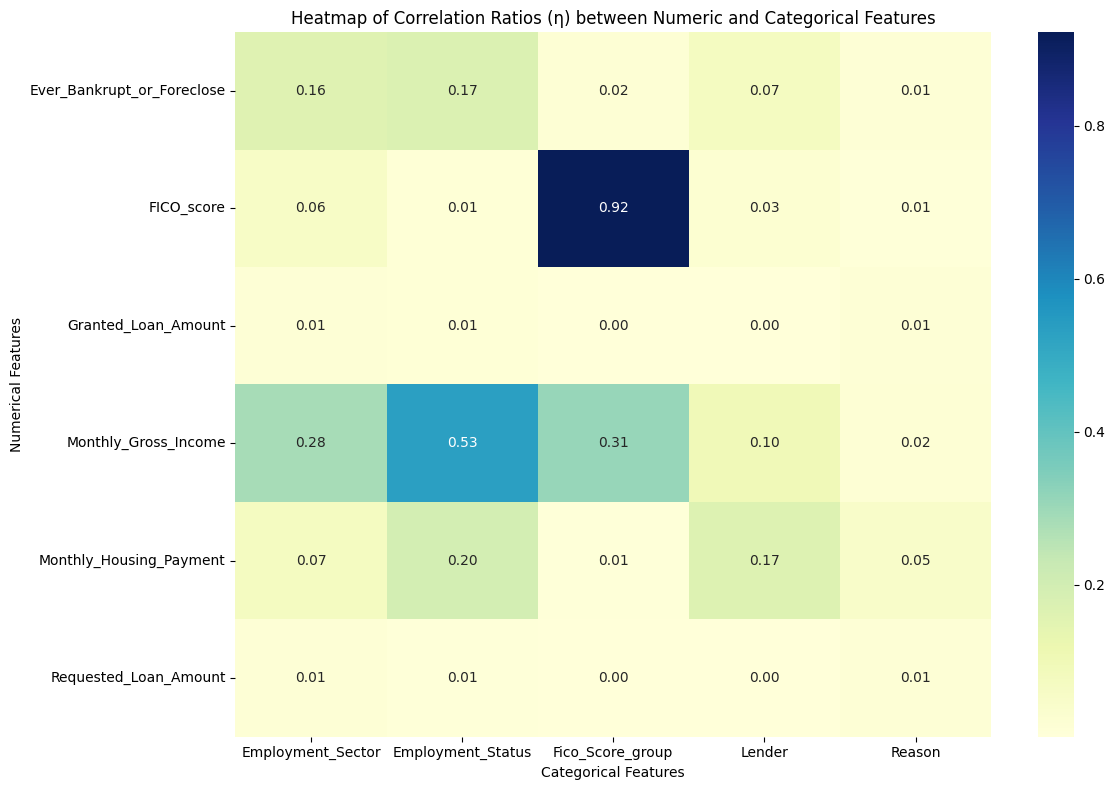

In [ ]:
# Correlation between Numeric and Categorical Variables (Correlation Ratio / η²)
from scipy import stats

def correlation_ratio(categories, values):
    categories = np.array(categories)
    values = np.array(values)
    cat_levels = np.unique(categories)
    overall_mean = np.mean(values)
    numerator = sum(len(values[categories == cat]) *
                    (np.mean(values[categories == cat]) - overall_mean) ** 2
                    for cat in cat_levels)
    denominator = sum((values - overall_mean) ** 2)
    return np.sqrt(numerator / denominator) if denominator != 0 else 0

# test all numeric–categorical pairs
num_cat_results = []

# Apply imputation to df_clean for consistency with df_copy before further processing
df_clean['FICO_score'] = df_clean['FICO_score'].fillna(df_clean['FICO_score'].median())
df_clean['Monthly_Gross_Income'] = df_clean['Monthly_Gross_Income'].fillna(df_clean['Monthly_Gross_Income'].median())
df_clean['Employment_Sector'] = df_clean['Employment_Sector'].fillna('Unknown')

# Identify categorical and numerical columns
categorical_cols_clean = df_clean.select_dtypes(include='object').columns.tolist()
numeric_cols_clean = df_clean.select_dtypes(include=np.number).columns.tolist()


numeric_cols_for_eta = [col for col in numeric_cols_clean if col not in ['bounty', 'Approved', ]]
categorical_cols_for_eta = [col for col in categorical_cols_clean]


for num_col in numeric_cols_for_eta:
    for cat_col in categorical_cols_for_eta:
        eta = correlation_ratio(df_clean[cat_col], df_clean[num_col])
        num_cat_results.append((num_col, cat_col, eta))

num_cat_results = sorted(num_cat_results, key=lambda x: x[2], reverse=True)
print("Top 10 Numeric-Categorical Correlation Ratios (η²):")
for num_col, cat_col, eta in num_cat_results[:10]:
    print(f"{num_col} - {cat_col}: η² = {eta**2:.3f} (η = {eta:.3f})")


# Reorganize the correlation ratio results into a pivot table/matrix for heatmap
eta_matrix = pd.DataFrame(num_cat_results, columns=['Numerical_Feature', 'Categorical_Feature', 'Eta'])
eta_pivot = eta_matrix.pivot(index='Numerical_Feature', columns='Categorical_Feature', values='Eta')

# Plot the heatmap of correlation ratios (Eta)
plt.figure(figsize=(12, 8))
sns.heatmap(eta_pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap of Correlation Ratios (η) between Numeric and Categorical Features")
plt.xlabel("Categorical Features")
plt.ylabel("Numerical Features")
plt.tight_layout()
plt.show()

**Questions:** What features will you consider dropping after analyzing the graphs above?

**Answer** : Approved, bounty, and Granted_Loan_Amount were dropped before modeling to prevent target leakage and keep the model realistic. Approved is the target variable, so it cannot be included as a predictor. bounty was removed because it is only received when an application is approved, meaning it directly depends on the outcome. Granted_Loan_Amount was also removed because it likely represents information determined after the lender’s decision, so it would not be available at the time of prediction. Removing these variables helps ensure the model learns from information available before the approval decision rather than from outcome-related fields.

Note: Granted_Loan_Amount is seen below because it is a part of the code chunks that were provided by the professor in this notebook. It is included to be consisted with what we were given in the instructions. In our final app, adjusting this value does not have a significant impact on the prediction overall.



> *Note: For Decision Tree models, you do not need to remove or adjust for collinearity. The algorithm can naturally handle correlated features through its splitting mechanism. However, for Logistic Regression, multicollinearity can distort coefficient estimates and make interpretations unreliable. In that case, you may consider removing one variable from highly correlated pairs.


In [ ]:
# Define target
y = df_model['Approved']

# Drop target and leakage variables before train/test split
cols_to_drop = [
    'Approved',
    'bounty',
    'Granted_Loan_Amount'
]

X_pre_encode = df_model.drop(columns=cols_to_drop)

## 2. Exploratory Data Analysis

### 2.1 Target Variable Distribution

Analyze the distribution of the target variable (Approved) to understand class balance in loan approval outcomes.


**Question:**
Is the dataset balanced or imbalanced? Briefly explain the implication for modeling.


**Answer:**
Add your answer here

/tmp/ipykernel_8911/3260114097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Approved', data=df_clean, palette='coolwarm')


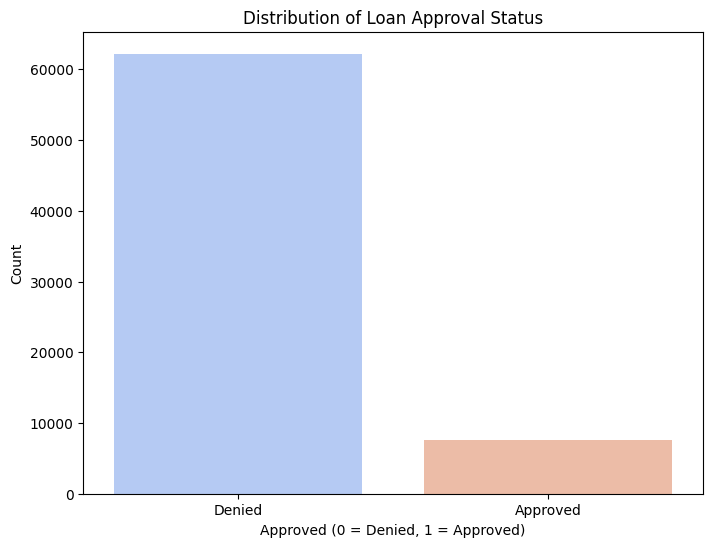

Loan Approval Distribution:
Approved
0    62207
1     7624
Name: count, dtype: int64

Loan Approval Percentage:
Approved
0    89.08
1    10.92
Name: proportion, dtype: float64


In [ ]:
# Plot 'Approved' to visualise the count and balance
plt.figure(figsize=(8, 6))
sns.countplot(x='Approved', data=df_clean, palette='coolwarm')
plt.title('Distribution of Loan Approval Status')
plt.xlabel('Approved (0 = Denied, 1 = Approved)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Denied', 'Approved'])
plt.show()

approved_counts = df_clean['Approved'].value_counts()
approved_percentage = df_clean['Approved'].value_counts(normalize=True) * 100

print("Loan Approval Distribution:")
print(approved_counts)
print("\nLoan Approval Percentage:")
print(approved_percentage.round(2))


### 2.2 Distribution of Numerical Variables by Approval

Explore how key numerical variables differ between approved and rejected loan applications.


**Question:**
Which numerical variable is the most helpful variable ( most crucial predictor) ?

**Answer:**
The most helpful variable would be FICO Score. Based on looking at the graphs, there is relatively least overlapping between the box plots where it is denied or approved based on the FICO score. The plot clearly indicates a trend that the higher the FICO score, the more likely it is to be approved.

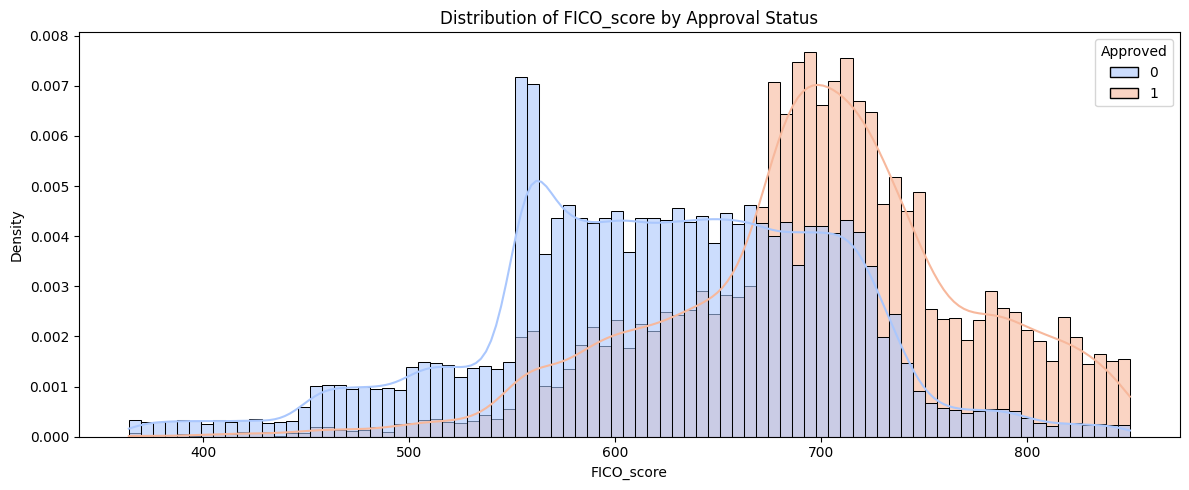

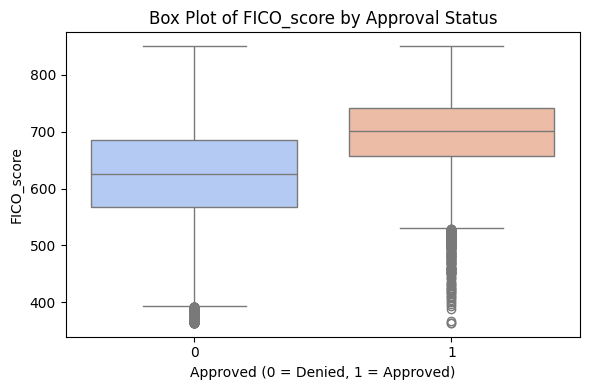

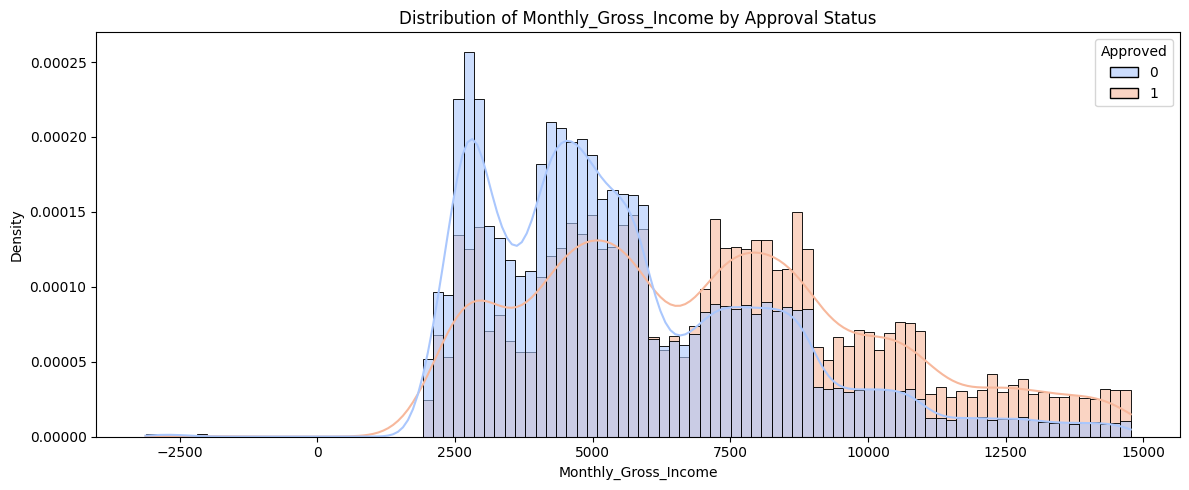

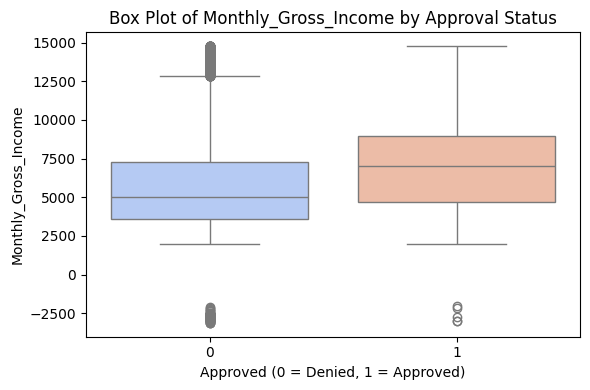

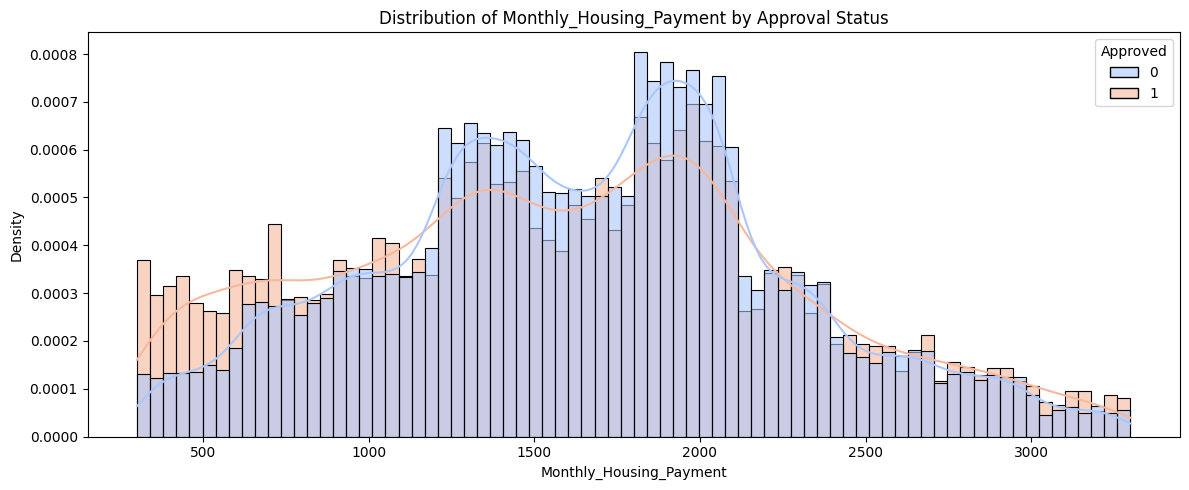

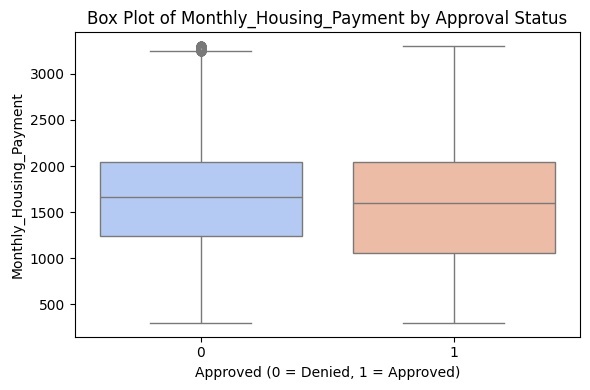

In [143]:
numerical_cols = ['FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment', 'Requested_Loan_Amount']

for col in numerical_cols:
    plt.figure(figsize=(12,5))
    sns.histplot(
        data=df_clean,
        x=col,
        hue='Approved',
        kde=True,
        stat='density',
        common_norm=False,
        palette='coolwarm',
        alpha=0.6
    )
    plt.title(f'Distribution of {col} by Approval Status')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=df_clean,
        x='Approved',
        y=col,
        hue='Approved',
        palette='coolwarm',
        legend=False
    )
    plt.title(f'Box Plot of {col} by Approval Status')
    plt.xlabel('Approved (0 = Denied, 1 = Approved)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### 2.3 Categorical Variables and Approval

Analyze how categorical variables (such as Employment_Sector, Loan_Purpose, or Residence_Type) relate to the loan approval outcome.


**Question:**
Which categorical variable appears to have the strongest relationship with loan approval, and how can you tell?

**Answer:**
Add your answer here


**Question:**
Are there any categories (e.g., Reason, Employment_Status) that appear to have minimal predictive value? Justify your answer with approval rate differences.

**Answer:**
Add your answer here

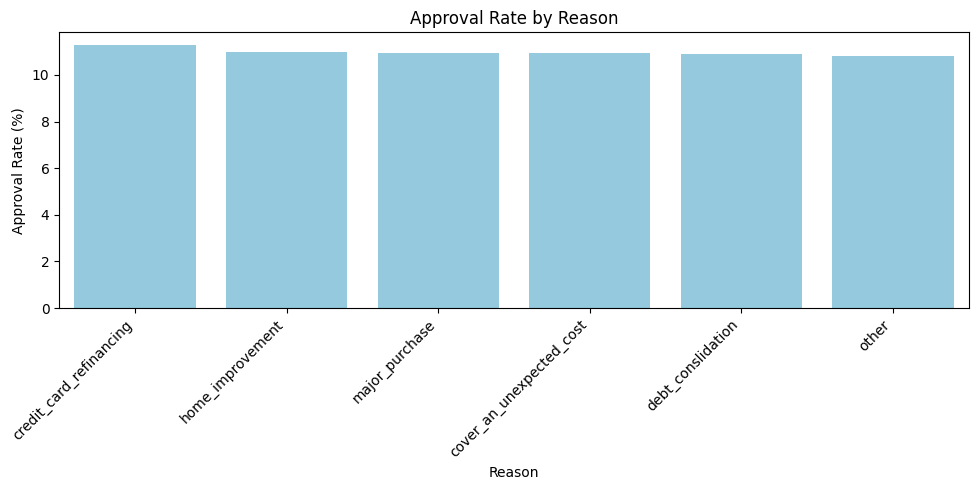


Approval Rate by Reason:
Reason
credit_card_refinancing     11.27
home_improvement            10.98
major_purchase              10.95
cover_an_unexpected_cost    10.93
debt_conslidation           10.89
other                       10.81
Name: Approved, dtype: float64


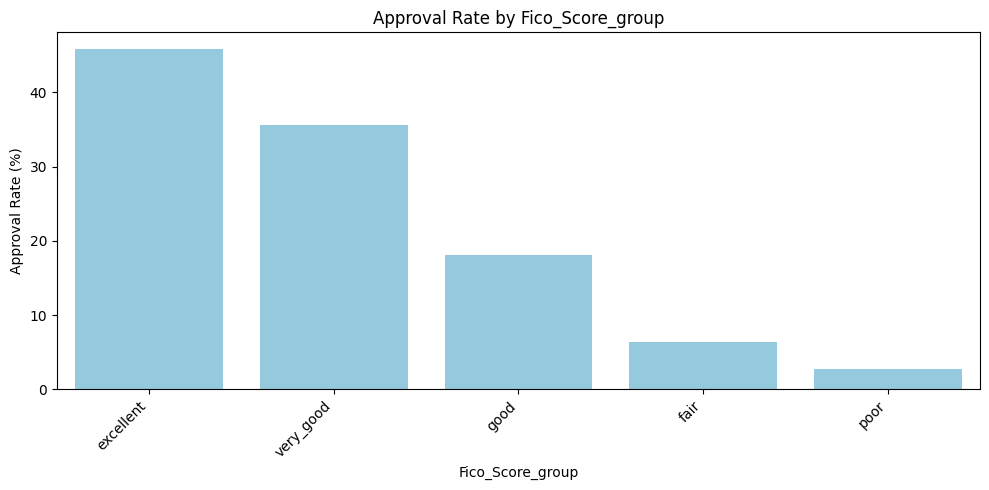


Approval Rate by Fico_Score_group:
Fico_Score_group
excellent    45.80
very_good    35.65
good         18.06
fair          6.44
poor          2.78
Name: Approved, dtype: float64


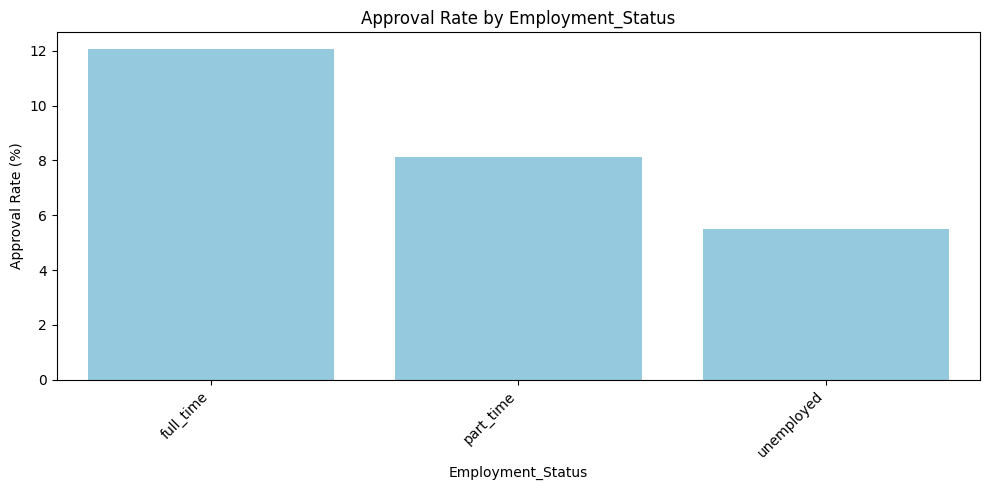


Approval Rate by Employment_Status:
Employment_Status
full_time     12.07
part_time      8.12
unemployed     5.49
Name: Approved, dtype: float64


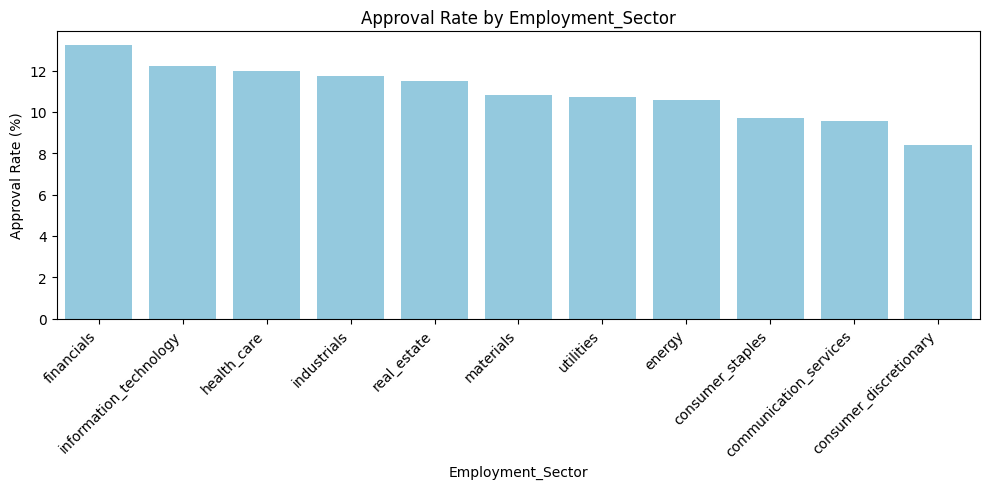


Approval Rate by Employment_Sector:
Employment_Sector
financials                13.24
information_technology    12.20
health_care               11.97
industrials               11.75
real_estate               11.50
materials                 10.83
utilities                 10.71
energy                    10.60
consumer_staples           9.68
communication_services     9.57
consumer_discretionary     8.42
Name: Approved, dtype: float64


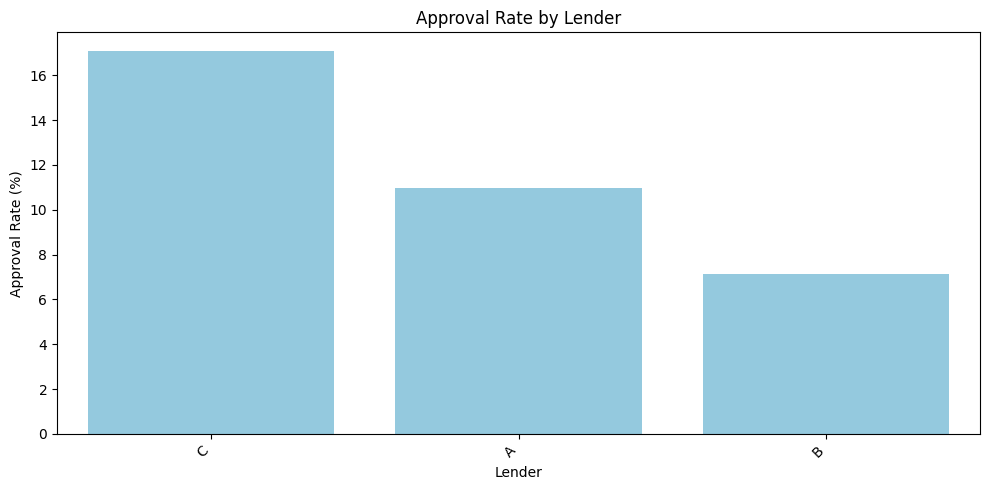


Approval Rate by Lender:
Lender
C    17.06
A    10.97
B     7.13
Name: Approved, dtype: float64


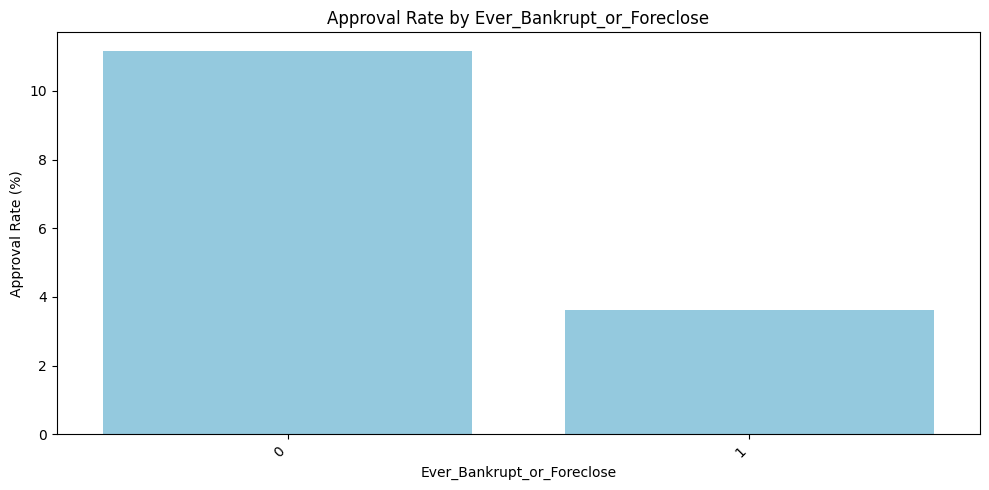


Approval Rate by Ever_Bankrupt_or_Foreclose:
Ever_Bankrupt_or_Foreclose
0    11.15
1     3.61
Name: Approved, dtype: float64


In [ ]:
# Visualise categorical variables against target variable

categorical_cols = [
    'Reason', 'Fico_Score_group', 'Employment_Status',
    'Employment_Sector', 'Lender', 'Ever_Bankrupt_or_Foreclose'
]

for col in categorical_cols:
    approval_rates = df.groupby(col)['Approved'].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(10,5))
    sns.barplot(x=approval_rates.index, y=approval_rates.values, color='skyblue')
    plt.title(f'Approval Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Approval Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nApproval Rate by {col}:\n{approval_rates.round(2)}")


### Cross Feature plots for multi-dimensional analysis.

<Figure size 1500x800 with 0 Axes>

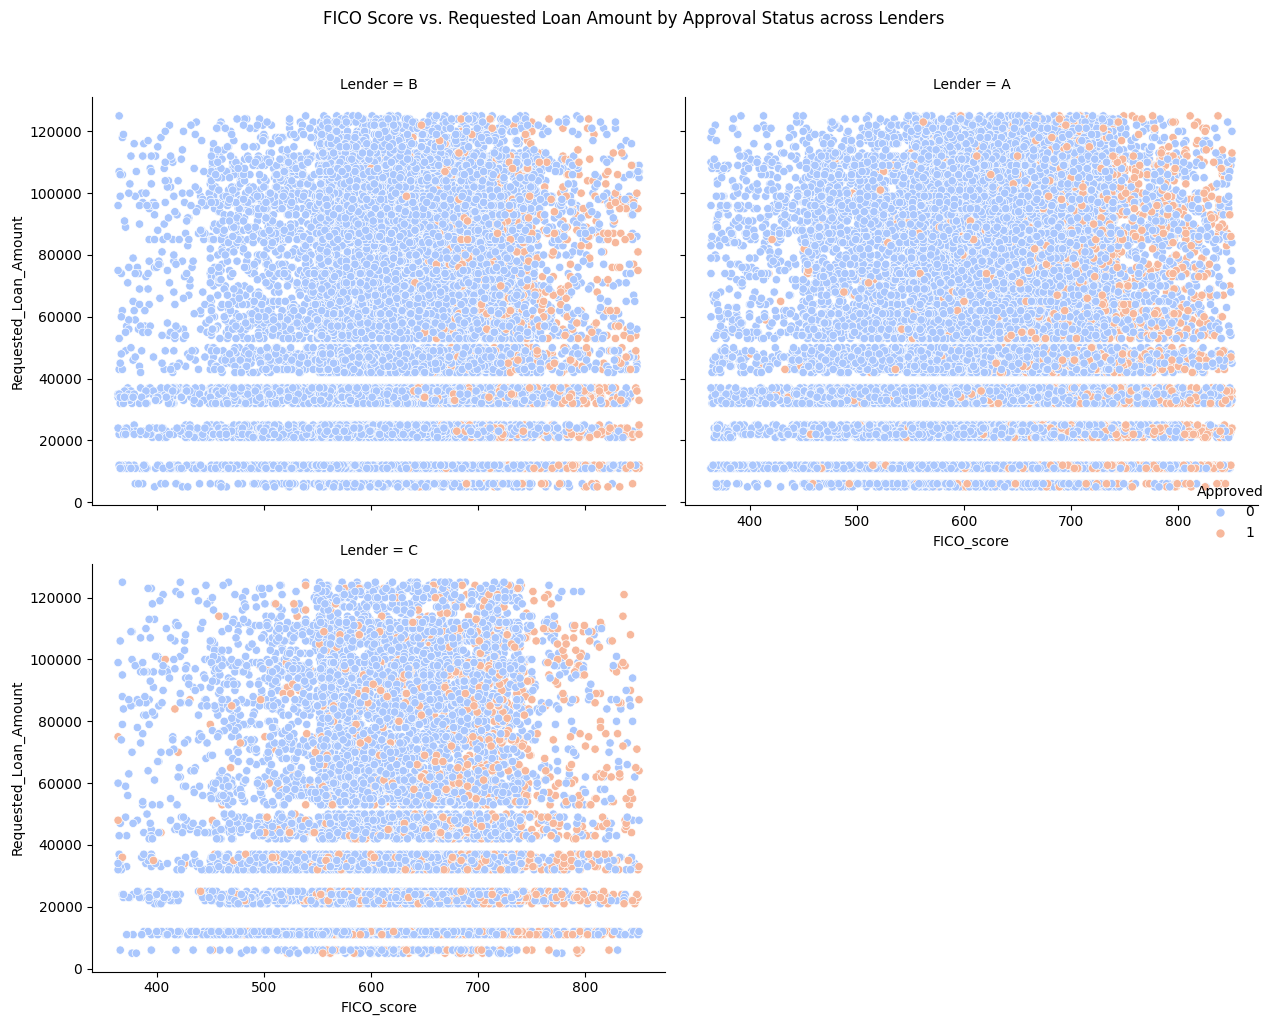

In [150]:
# Multi-dimensional analysis: FICO_score vs. Requested_Loan_Amount by Approved Status and Lender
plt.figure(figsize=(15, 8))
sns.relplot(
    data=df_clean,
    x='FICO_score',
    y='Requested_Loan_Amount',
    hue='Approved',
    col='Lender',
    kind='scatter',
    palette='coolwarm',
    height=5, aspect=1.2,
    col_wrap=2 # Wrap columns if there are many lenders
)
plt.suptitle('FICO Score vs. Requested Loan Amount by Approval Status across Lenders', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

<Figure size 1500x800 with 0 Axes>

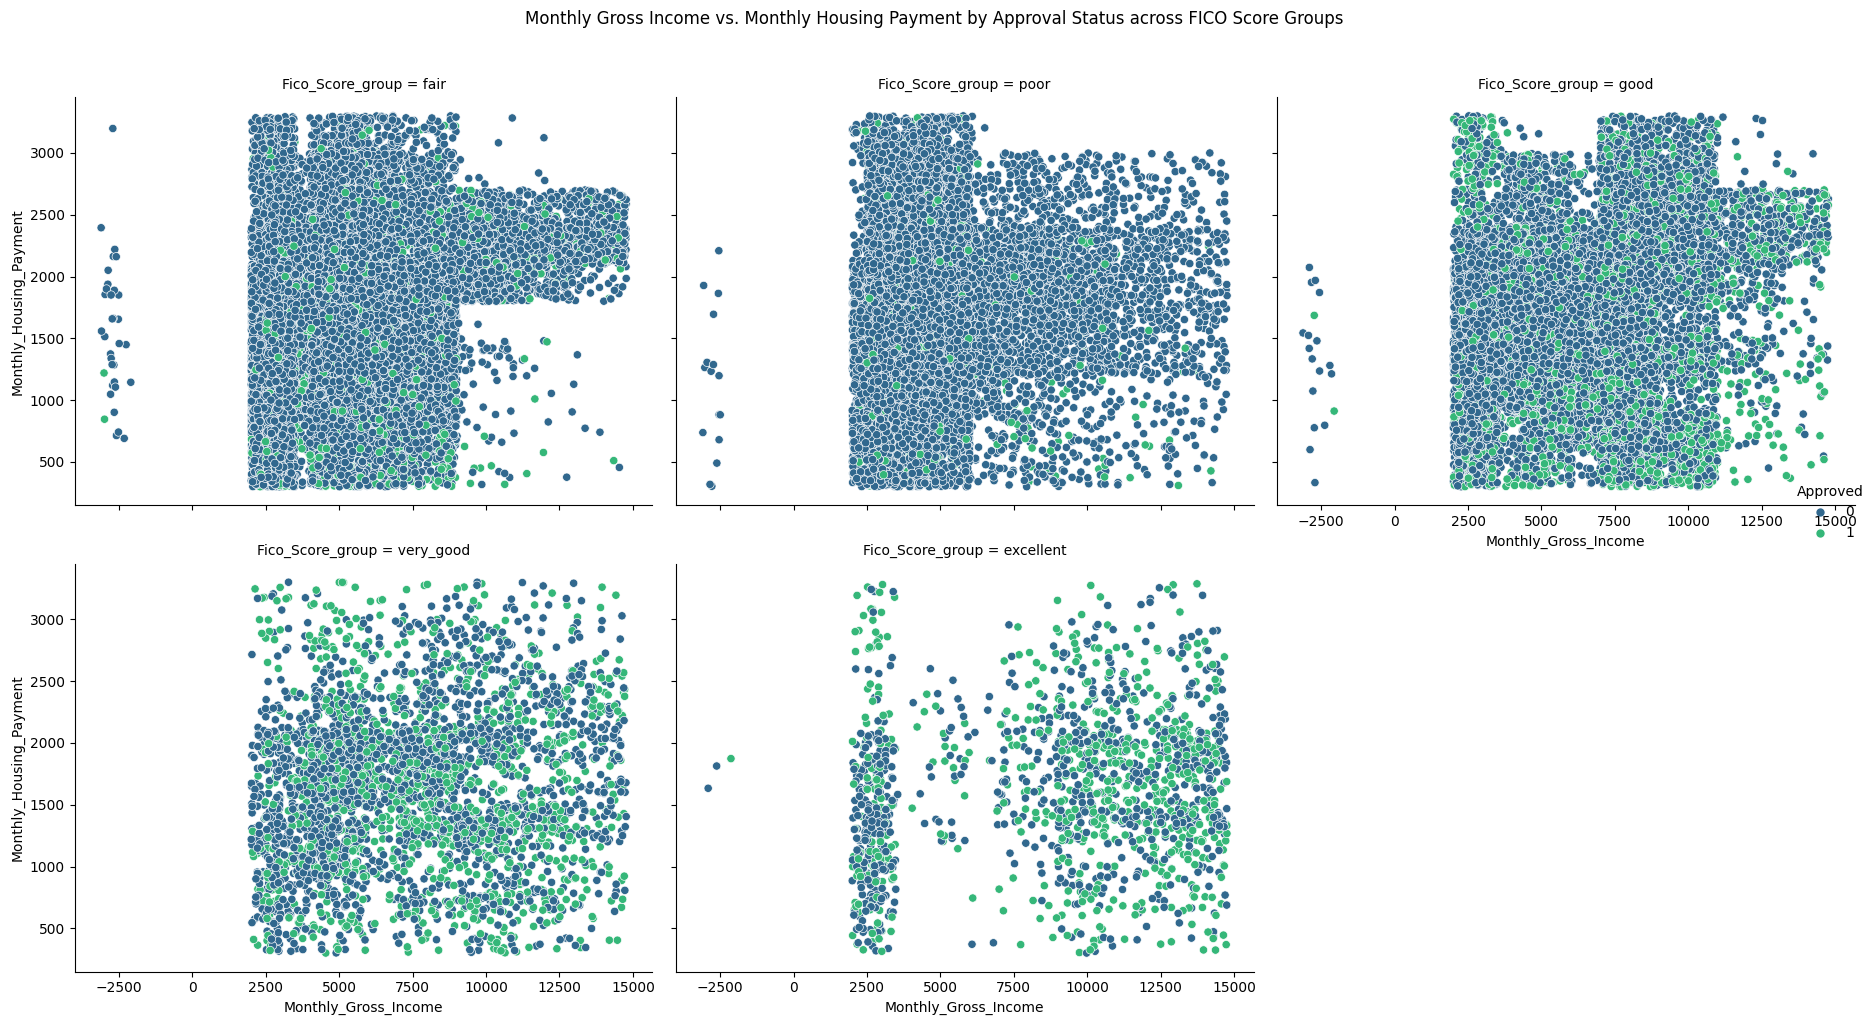

In [ ]:
# Multi-dimensional analysis: Monthly_Gross_Income vs. Monthly_Housing_Payment by Approved Status and Fico_Score_group
plt.figure(figsize=(15, 8))
sns.relplot(
    data=df_clean,
    x='Monthly_Gross_Income',
    y='Monthly_Housing_Payment',
    hue='Approved',
    col='Fico_Score_group',
    kind='scatter',
    palette='viridis',
    height=5, aspect=1.2,
    col_wrap=3 # Wrap columns if there are many FICO groups
)
plt.suptitle('Monthly Gross Income vs. Monthly Housing Payment by Approval Status across FICO Score Groups', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

## 3.5 Business Insights from EDA

After completing your visualizations and cross-feature analyses, summarize your findings in the context of loan approval and lender matching.  
Use this section to connect data patterns to real-world meaning before building predictive models.


**Question:** Which variables are the most helpful in understanding if a customer is going to be approved or denied for a loan?  

**Answer**: Add your answer here

**Question:** Are there any feature modifications or transformations that would improve the predictive power of a variable?  

**Answer**: Add your answer here

**Question:** What is each lender’s average approval rate?  

**Answer**: Add your answer here

**Question:** Are there any clear differences between the three lenders in terms of which types of customers they approve?  

**Answer**: Add your answer here

**Question:** Are there variables that reliably predict a customer’s approval likelihood for a particular lender?  

**Answer**: Add your answer here



> Treat this section as your interpretation bridge between EDA and modeling. The goal is to show that you understand *why* certain patterns exist, not just that they exist.


## 3. Model Training

### 3.1 Train/Test Split and Encoding

In [151]:
from sklearn.model_selection import train_test_split

# Rename your df to df_model.
df_model = df_clean.copy()

# Separate target variable 'Approved'
y = df_model['Approved']

# Drop target variable and 'bounty' from features (as requested)
X_pre_encode = df_model.drop(columns=['Approved', 'bounty','Granted_Loan_Amount'])

# Encode categorical features
categorical_features = X_pre_encode.select_dtypes(include='object').columns
X = pd.get_dummies(X_pre_encode, columns=categorical_features, drop_first=True) # drop_first to avoid multicollinearity

# Set RANDOM_STATE = 42 for reproducibility.
random_state = 42

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y) # stratify to maintain class balance

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (55864, 28)
Shape of X_test: (13967, 28)
Shape of y_train: (55864,)
Shape of y_test: (13967,)


### 3.2 Logistic Regression Model
Build and interpret a Logistic Regression model to predict the likelihood of loan approval (Approved = 1).

**Question**
How accurate is the model on the test data, and what does this imply about its predictive strength?

**Answer**
Add your answer here


In [152]:
from sklearn.linear_model import LogisticRegression

# Train logistic regression model
log_reg_model = LogisticRegression(random_state=random_state, solver='liblinear', class_weight='balanced')
# Added class_weight='balanced' due to imbalance
log_reg_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')

Logistic Regression Model Evaluation:
Accuracy: 0.7180
Precision: 0.2419
Recall: 0.7416
F1-Score: 0.3648
ROC-AUC: 0.8052


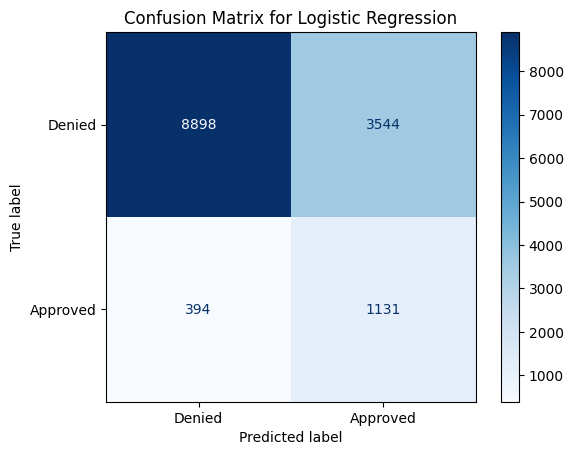

In [153]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

y_pred_log_reg = log_reg_model.predict(X_test)
y_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_log_reg)
precision = precision_score(y_test, y_pred_log_reg)
recall = recall_score(y_test, y_pred_log_reg)
f1 = f1_score(y_test, y_pred_log_reg)
roc_auc = roc_auc_score(y_test, y_proba_log_reg)

print(f"Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log_reg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Denied', 'Approved'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

### 3.2 Decision Tree Classifier Model

Build and interpret a Decision Tree Classifier Model to predict the likelihood of loan approval (Approved = 1).



**Question**
How does the Decision Tree’s accuracy and AUC compare to the Logistic Regression model?

**Answer**
Add your answer here


In [154]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=random_state, class_weight='balanced')
decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

Decision Tree Model Evaluation:
Accuracy: 0.8371
Precision: 0.2608
Recall: 0.2682
F1-Score: 0.2645
ROC-AUC: 0.5875


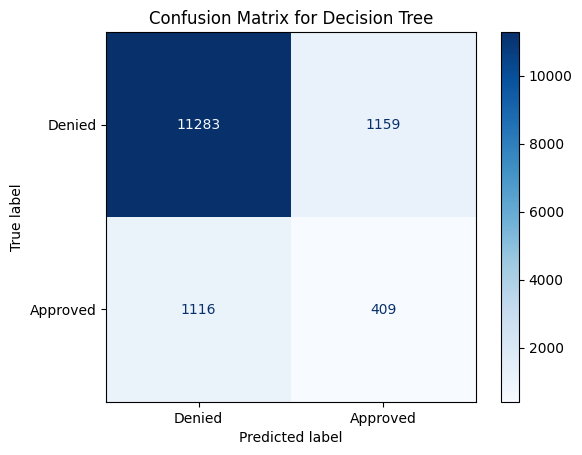

In [155]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

y_pred_dt = decision_tree_model.predict(X_test)
y_proba_dt = decision_tree_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)

print(f"Decision Tree Model Evaluation:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"ROC-AUC: {roc_auc_dt:.4f}")

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Denied', 'Approved'])
disp_dt.plot(cmap='Blues')
plt.title('Confusion Matrix for Decision Tree')
plt.show()

In [156]:
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': decision_tree_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top features for Decision Tree:")
print(feature_importances.head(10))

Top features for Decision Tree:
                                     feature  importance
1                                 FICO_score    0.291851
3                    Monthly_Housing_Payment    0.173483
2                       Monthly_Gross_Income    0.163537
0                      Requested_Loan_Amount    0.116708
27                                  Lender_C    0.037516
26                                  Lender_B    0.024192
11                     Fico_Score_group_good    0.017829
22  Employment_Sector_information_technology    0.013741
20             Employment_Sector_health_care    0.013686
6                   Reason_debt_conslidation    0.012327


### Compare the performance of the Logistic Regression and Decision Tree models.


1.   Compare the performance of the Logistic Regression and Decision Tree
models.
2.   Evaluate and compare both models using key metrics such as ROC-AUC, Accuracy, Precision, Recall, and F1-score.
3. Plot and interpret the confusion matrices for both models. Discuss what false positives and false negatives mean in the business context (for example, approving risky applicants vs. rejecting qualified ones).
4. Identify which model best captures the target event (loan approval) and explain why.
5. Justify your model choice from both technical (performance, interpretability) and business (actionability, trust, and decision-making) perspectives.
6. Indicate the cutoff threshold you used and why it makes sense for this scenario.

The Logistic Regression model performs best for the business goal because it is much better at identifying applicants who are actually approved. Although the Decision Tree has higher accuracy, it has very low recall, meaning it misses most approved applicants. Logistic Regression has a stronger recall, F1-score, and ROC-AUC, making it better for understanding approval likelihood and helping the business identify qualified applicants. The trade-off is that Logistic Regression produces more false positives, but for this business problem, missing potentially approved customers may be more costly than reviewing some extra applicants.

In [157]:
model = log_reg_model

In [158]:
# Save your model as .pkl file for streamlit app development
import pickle

filename = 'my_model.pkl'  # Choose a path and descriptive filename with .pkl extension

# Open the file in binary write mode ('wb')
with open(filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved successfully to {filename}")

Model saved successfully to my_model.pkl


**Question:**
Which model do you recommend and why? (Provide both technical and business reasoning.)

**Answer:** Add your answer here

## 5. Recommendations
In this final section, summarize your key findings and provide concise business recommendations based on your analysis.


**Write a short paragraph including:**  
- A brief summary of your main findings from the analysis and model comparison.  
- The key factors that most influence loan approval.  
- Your recommendations on data or model based on the results  (for example, how approval decisions could be improved or better understood).  
- One next step you would take to improve the model or extend the analysis further.  


**Add your paragraph here:**



---



**Question:**  What trade-offs or risks should the company be aware of when using this model?  

**Answer:** Add your answer here

**Question:** How confident are you in your model’s generalizability — what might change its performance in real-world use?   

**Answer:** Add your answer here


**Question:** If you had access to additional data, what new feature would you collect to strengthen this model?

**Answer:** Add your answer here

### GitHub and App Links

https://github.com/zoeschuhler/final

https://iuma8xdotbtzdscpgww8xu.streamlit.app/

